# DuckQuake signal study: Portland State game vs a quiet weekday

Stations UO.DUCK1-3 in Autzen Stadium, accelerometers (HN?) at 200 Hz.

- **Game:** Fri 2026-09-18 PT. Kickoff 7:30 pm, end 11:56 pm (4 h 19 min, 84-0). Window 5:30 pm to 1:00 am.
- **Quiet:** Wed 2026-09-23 PT, same hours.

Data comes from `~/DuckQuake/data` via `scripts/download_archive.py`. Units are m/s² after removing the instrument sensitivity. Times on the plots are Pacific.

In [1]:
import tomllib
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import signal
from obspy import read, read_inventory, UTCDateTime

ROOT = Path.cwd().parent
cfg = tomllib.loads((ROOT / "config.toml").read_text())
DATA = Path(cfg["data"]["dir"]).expanduser()
STATIONS = cfg["source"]["stations"]
PT = ZoneInfo("America/Los_Angeles")
UTC = ZoneInfo("UTC")

KICKOFF = UTCDateTime("2026-09-19T02:30:00")   # 7:30 pm PT
GAME_END = UTCDateTime("2026-09-19T06:56:00")  # 11:56 pm PT
FS = 200.0
FMAX = 50  # spectrogram ceiling, Hz

inv = read_inventory(str(DATA / "stations" / "UO.xml"))

def load(dataset):
    """Return {station: Stream} with sensitivity removed, gaps interpolated, mean removed."""
    out = {}
    for sta in STATIONS:
        st = read(str(DATA / dataset / f"UO.{sta}.mseed"))
        st.merge(method=1, fill_value="interpolate")
        st.remove_sensitivity(inv)
        st.detrend("demean")
        for tr in st:
            tr.data = tr.data.astype(np.float32)
        out[sta] = st
    return out

def mpl_time(tr):
    """Matplotlib date numbers for every sample of a trace."""
    t0 = mdates.date2num(tr.stats.starttime.datetime.replace(tzinfo=UTC))
    return t0 + np.arange(tr.stats.npts) / tr.stats.sampling_rate / 86400

def fmt_pt(ax, fmt="%H:%M"):
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt, tz=PT))

def mark_game(ax):
    for t in (KICKOFF, GAME_END):
        ax.axvline(mdates.date2num(t.datetime.replace(tzinfo=UTC)), color="k", ls="--", lw=0.8)

def spec(tr, nperseg):
    f, t, S = signal.spectrogram(tr.data, fs=FS, nperseg=nperseg, noverlap=nperseg // 2, scaling="density")
    t0 = mdates.date2num(tr.stats.starttime.datetime.replace(tzinfo=UTC))
    return f, t0 + t / 86400, 10 * np.log10(S + 1e-30)

def rms(x, n):
    m = len(x) // n
    return np.sqrt((x[: m * n].reshape(m, n) ** 2).mean(axis=1))

game = load("psu_game")
quiet = load("quiet_weekday")
for sta in STATIONS:
    print(sta, "game:", [f"{tr.stats.channel} {tr.stats.npts}" for tr in game[sta]],
          "| quiet:", [f"{tr.stats.channel} {tr.stats.npts}" for tr in quiet[sta]])

DUCK1 game: ['HNE 5400001', 'HNN 5400001', 'HNZ 5400001'] | quiet: ['HNE 5400001', 'HNN 5400001', 'HNZ 5400001']
DUCK2 game: ['HNE 5400001', 'HNN 5400001', 'HNZ 5400001'] | quiet: ['HNE 5400001', 'HNN 5400001', 'HNZ 5400001']
DUCK3 game: ['HNN 5400001', 'HNE 5400001', 'HNZ 5400001'] | quiet: ['HNE 5400001', 'HNN 5400001', 'HNZ 5400001']


## 1. Vertical acceleration, full window, broadband

Each panel is the 1-second min/max envelope of HNZ, highpassed at 0.5 Hz to remove drift. Game and quiet share the y-axis per station. Dashed lines are kickoff and the end of the game.

Note the scale on DUCK2: its background is about 100 times DUCK1 and DUCK3. Section 2 shows why.

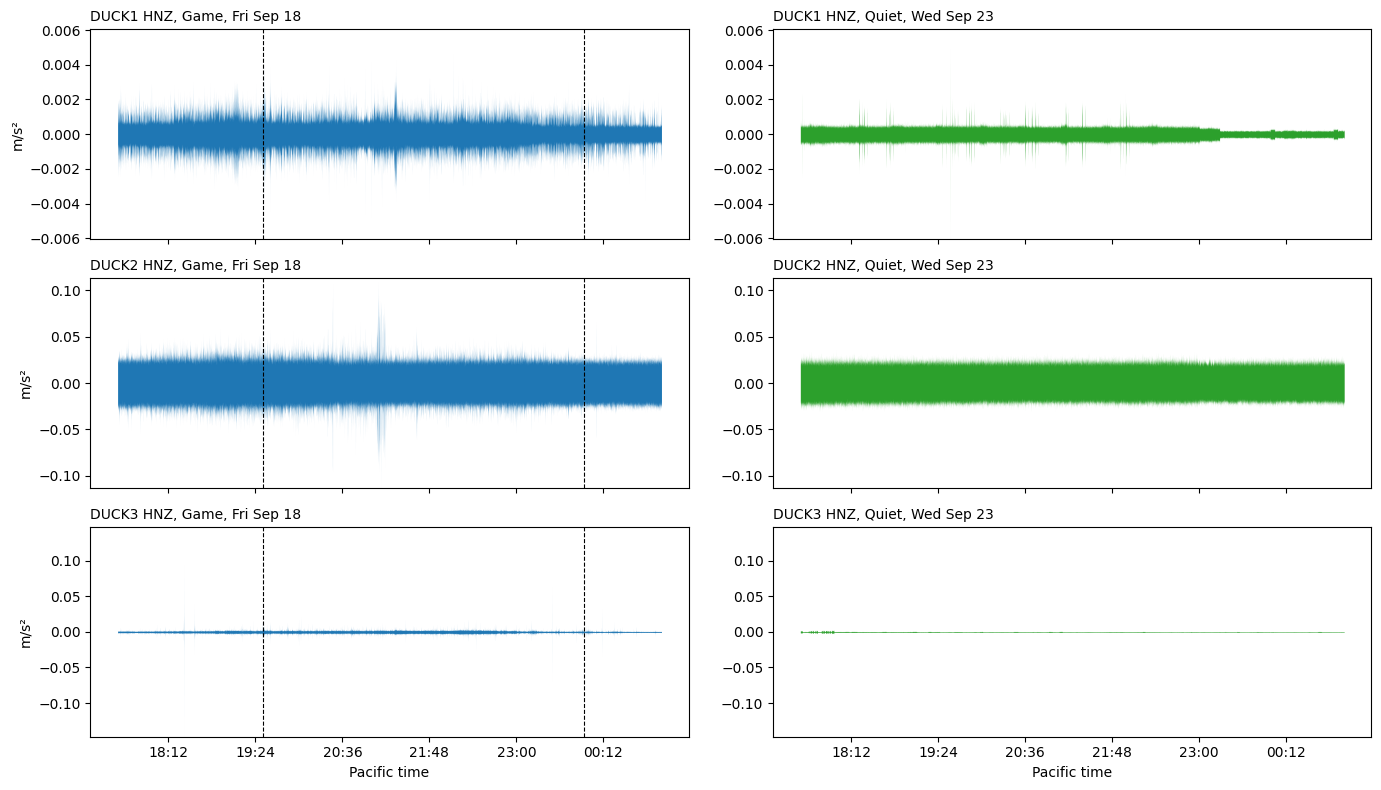

In [2]:
def minmax_envelope(x, n):
    m = len(x) // n
    y = x[: m * n].reshape(m, n)
    return y.min(axis=1), y.max(axis=1)

fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex="col")
for i, sta in enumerate(STATIONS):
    ylim = 0
    for j, (label, ds) in enumerate((("Game, Fri Sep 18", game), ("Quiet, Wed Sep 23", quiet))):
        tr = ds[sta].select(channel="HNZ")[0].copy().filter("highpass", freq=0.5, zerophase=True)
        lo, hi = minmax_envelope(tr.data, int(FS))
        t = mpl_time(tr)[:: int(FS)][: len(lo)]
        ax = axes[i, j]
        ax.fill_between(t, lo, hi, color="C0" if j == 0 else "C2", lw=0)
        ax.set_title(f"{sta} HNZ, {label}", loc="left", fontsize=10)
        fmt_pt(ax)
        if j == 0:
            mark_game(ax)
        ylim = max(ylim, np.abs(hi).max(), np.abs(lo).max())
    for ax in axes[i]:
        ax.set_ylim(-ylim, ylim)
    axes[i, 0].set_ylabel("m/s²")
for ax in axes[-1]:
    ax.set_xlabel("Pacific time")
fig.tight_layout()

## 2. Spectrograms, 0 to 50 Hz

10-second windows, 50 % overlap, power in dB relative to 1 (m/s²)²/Hz. Game and quiet share one color scale per station.

DUCK2 carries strong steady lines near 33 and 41 Hz on both nights, plus bursts up to 50 Hz. That is machinery near the sensor, not the crowd, and it is what inflates DUCK2's broadband amplitude in section 1.

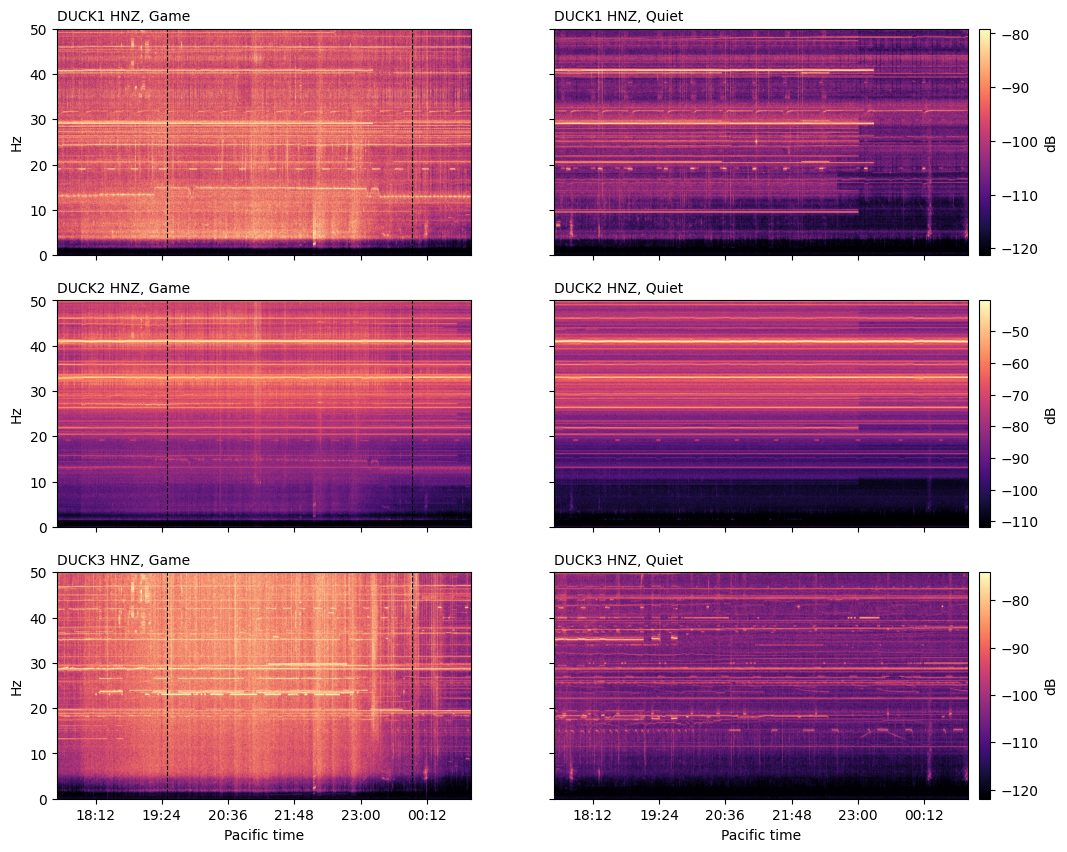

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex="col", sharey=True)
for i, sta in enumerate(STATIONS):
    specs = []
    for ds in (game, quiet):
        f, t, S = spec(ds[sta].select(channel="HNZ")[0], nperseg=2000)
        keep = f <= FMAX
        specs.append((f[keep], t, S[keep]))
    allS = np.concatenate([s[2].ravel() for s in specs])
    vmin, vmax = np.percentile(allS, [5, 99.5])
    for j, ((f, t, S), label) in enumerate(zip(specs, ("Game", "Quiet"))):
        ax = axes[i, j]
        im = ax.imshow(S, aspect="auto", origin="lower", extent=[t[0], t[-1], f[0], f[-1]],
                       vmin=vmin, vmax=vmax, cmap="magma")
        ax.set_title(f"{sta} HNZ, {label}", loc="left", fontsize=10)
        fmt_pt(ax)
        if j == 0:
            mark_game(ax)
    axes[i, 0].set_ylabel("Hz")
    fig.colorbar(im, ax=axes[i, :], pad=0.01, label="dB")
for ax in axes[-1]:
    ax.set_xlabel("Pacific time")

## 3. Where is the crowd signal? Power spectra during the game

Welch PSD over the in-game hours (kickoff to end) versus the same hours on the quiet night, all three components. The bottom row is the ratio game/quiet: the band where the crowd stands out most against background. This sets the band for the envelope below, the fan shake meter, and the relay's default bandpass.

Mean game/quiet ratio (dB) on HNZ by octave band:
   0.5-1    Hz: DUCK1   0.3  DUCK2   4.9  DUCK3   7.3
     1-2    Hz: DUCK1  15.2  DUCK2  18.3  DUCK3  20.5
     2-4    Hz: DUCK1  19.7  DUCK2  16.3  DUCK3  21.2
     4-8    Hz: DUCK1  21.5  DUCK2  17.6  DUCK3  21.6
     8-16   Hz: DUCK1  13.4  DUCK2   9.7  DUCK3  14.5
    16-32   Hz: DUCK1   4.9  DUCK2   3.5  DUCK3  16.9
    32-64   Hz: DUCK1   5.9  DUCK2   1.5  DUCK3  12.8


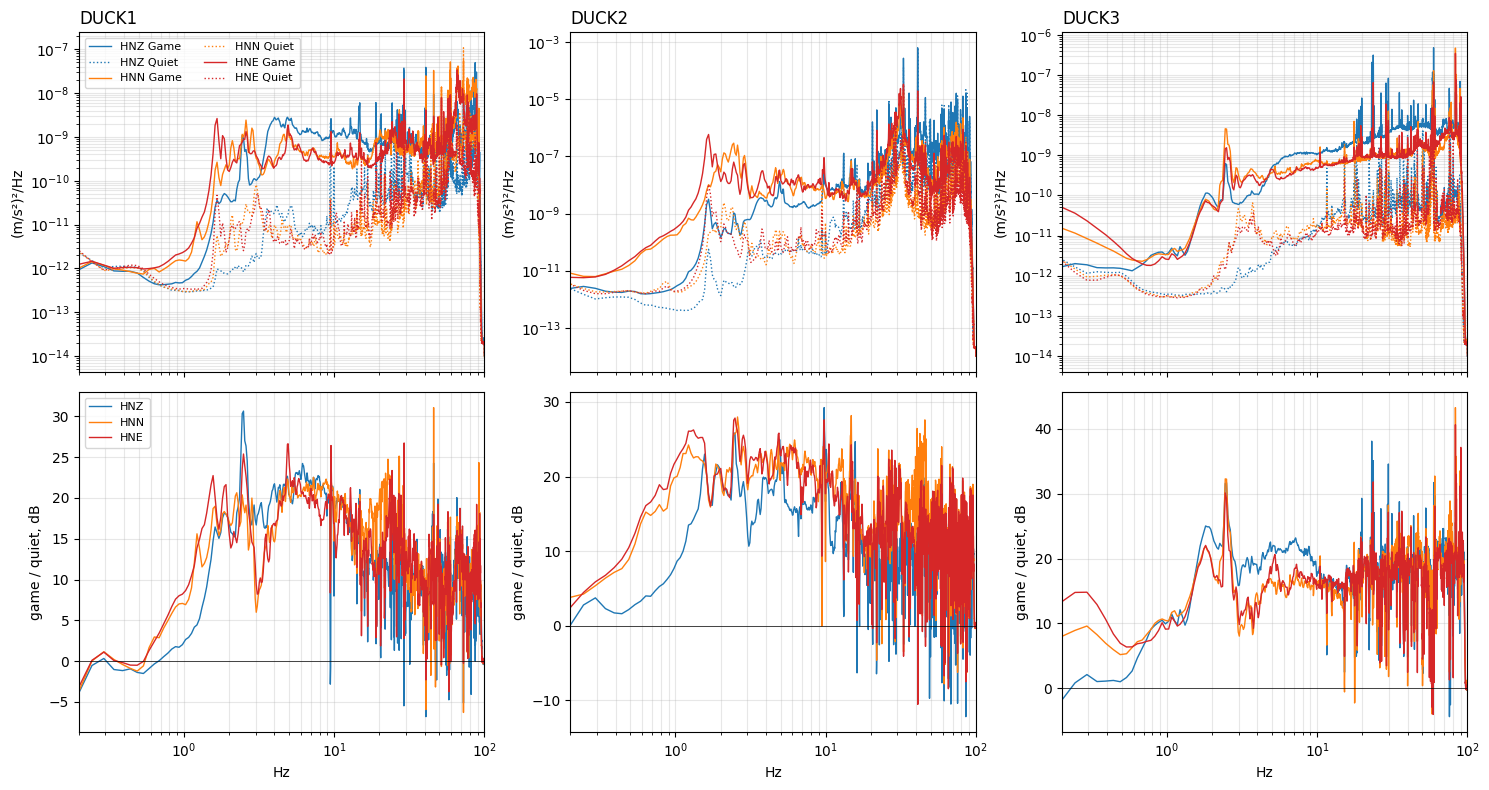

In [4]:
def slice_game_hours(tr):
    off0 = KICKOFF - UTCDateTime("2026-09-19T00:30:00")
    off1 = GAME_END - UTCDateTime("2026-09-19T00:30:00")
    return tr.slice(tr.stats.starttime + off0, tr.stats.starttime + off1)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
psd = {}
for i, sta in enumerate(STATIONS):
    for ch, c in (("HNZ", "C0"), ("HNN", "C1"), ("HNE", "C3")):
        for label, ds, ls in (("Game", game, "-"), ("Quiet", quiet, ":")):
            seg = slice_game_hours(ds[sta].select(channel=ch)[0])
            f, P = signal.welch(seg.data, fs=FS, nperseg=4096, scaling="density")
            psd[(sta, ch, label)] = (f, P)
            axes[0, i].loglog(f, P, color=c, ls=ls, lw=1, label=f"{ch} {label}")
        fg, Pg = psd[(sta, ch, "Game")]
        _, Pq = psd[(sta, ch, "Quiet")]
        axes[1, i].semilogx(fg, 10 * np.log10(Pg / Pq), color=c, lw=1, label=ch)
    axes[0, i].set_title(sta, loc="left")
    axes[0, i].set_ylabel("(m/s²)²/Hz")
    axes[1, i].set_ylabel("game / quiet, dB")
    axes[1, i].set_xlabel("Hz")
    axes[1, i].axhline(0, color="k", lw=0.5)
    for ax in axes[:, i]:
        ax.set_xlim(0.2, 100)
        ax.grid(alpha=0.3, which="both")
axes[0, 0].legend(fontsize=8, ncol=2)
axes[1, 0].legend(fontsize=8)
fig.tight_layout()

print("Mean game/quiet ratio (dB) on HNZ by octave band:")
for lo, hi in ((0.5, 1), (1, 2), (2, 4), (4, 8), (8, 16), (16, 32), (32, 64)):
    row = []
    for sta in STATIONS:
        f, Pg = psd[(sta, "HNZ", "Game")]
        _, Pq = psd[(sta, "HNZ", "Quiet")]
        m = (f >= lo) & (f < hi)
        row.append(10 * np.log10(Pg[m].mean() / Pq[m].mean()))
    print(f"  {lo:>4}-{hi:<4} Hz: " + "  ".join(f"{sta} {v:5.1f}" for sta, v in zip(STATIONS, row)))

## 4. Crowd-band RMS envelope, game vs quiet

10-second RMS of the vertical, bandpassed to the crowd band from section 3, on a log scale. The quiet night is drawn on the game's clock so the hours line up. This is the shape a fan shake meter would show.

Median in-game / median quiet RMS in the 1-10 Hz band:
  DUCK1: 8.98e-05 / 1.26e-05 =   7.1x
  DUCK2: 1.18e-04 / 1.87e-05 =   6.3x
  DUCK3: 6.57e-05 / 5.68e-06 =  11.6x


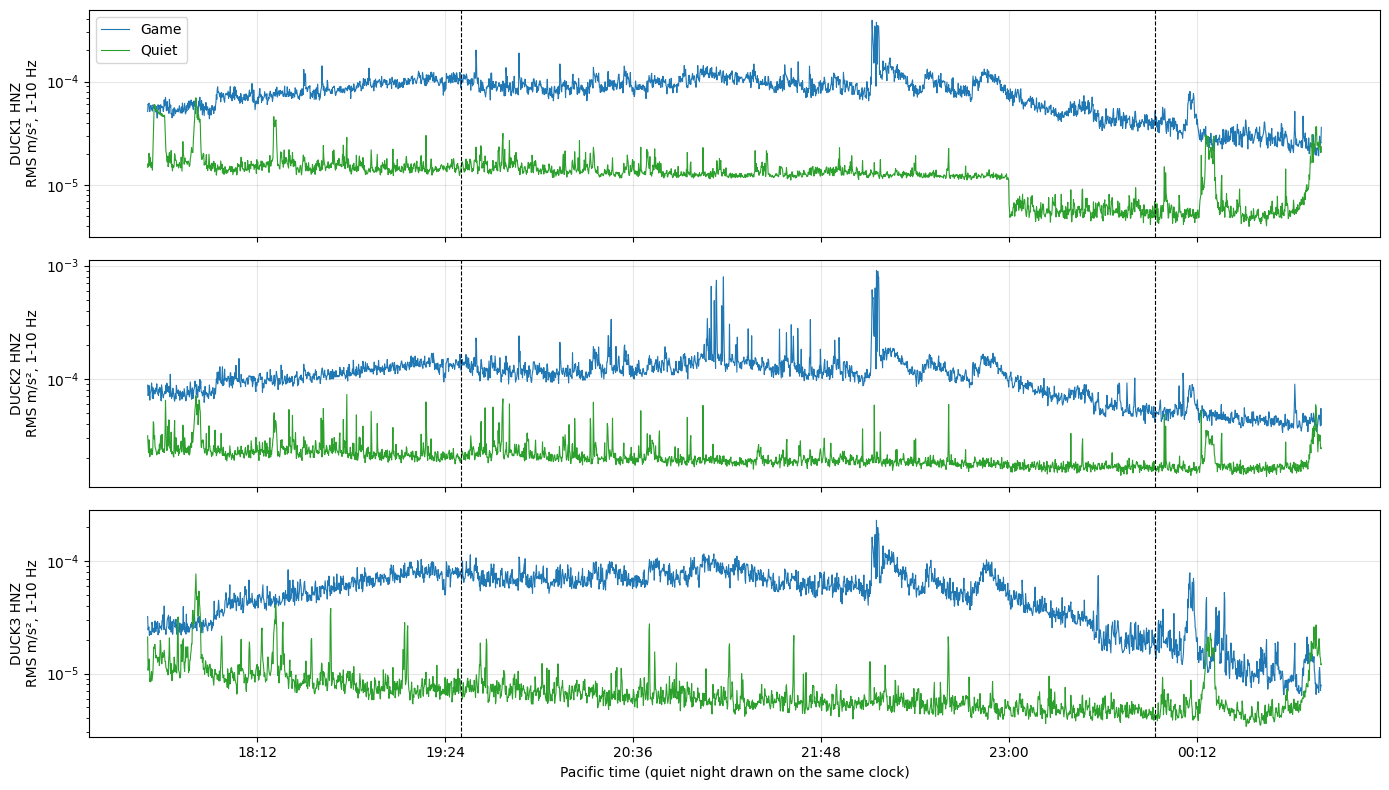

In [5]:
BAND = (1.0, 10.0)   # Hz, from section 3
WIN = 10             # s

def band_rms(tr, band=BAND, win=WIN):
    x = tr.copy().filter("bandpass", freqmin=band[0], freqmax=band[1], zerophase=True)
    return rms(x.data, int(win * FS))

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
env = {}
for i, sta in enumerate(STATIONS):
    ax = axes[i]
    ref = game[sta].select(channel="HNZ")[0]
    t = mpl_time(ref)[:: int(WIN * FS)]
    for label, ds, c in (("Game", game, "C0"), ("Quiet", quiet, "C2")):
        r = band_rms(ds[sta].select(channel="HNZ")[0])
        env[(sta, label)] = r
        ax.semilogy(t[: len(r)], r, color=c, lw=0.8, label=label)
    mark_game(ax)
    fmt_pt(ax)
    ax.set_ylabel(f"{sta} HNZ\nRMS m/s², {BAND[0]:g}-{BAND[1]:g} Hz")
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper left")
axes[-1].set_xlabel("Pacific time (quiet night drawn on the same clock)")
fig.tight_layout()

print(f"Median in-game / median quiet RMS in the {BAND[0]:g}-{BAND[1]:g} Hz band:")
k0 = int((KICKOFF - UTCDateTime("2026-09-19T00:30:00")) / WIN)
k1 = int((GAME_END - UTCDateTime("2026-09-19T00:30:00")) / WIN)
for sta in STATIONS:
    g, q = env[(sta, "Game")][k0:k1], env[(sta, "Quiet")][k0:k1]
    print(f"  {sta}: {np.median(g):.2e} / {np.median(q):.2e} = {np.median(g)/np.median(q):5.1f}x")

## 5. The loudest five minutes in the crowd band

Found from the peak of the band-limited 10-second RMS across all three stations during the game. Top three: vertical traces bandpassed to the crowd band. Bottom: 2-second-window spectrogram of the loudest station, the resolution the live lab view will use.

loudest 10 s in 1-10 Hz: DUCK2 at 22:09:20 PT, RMS 9.08e-04 m/s²


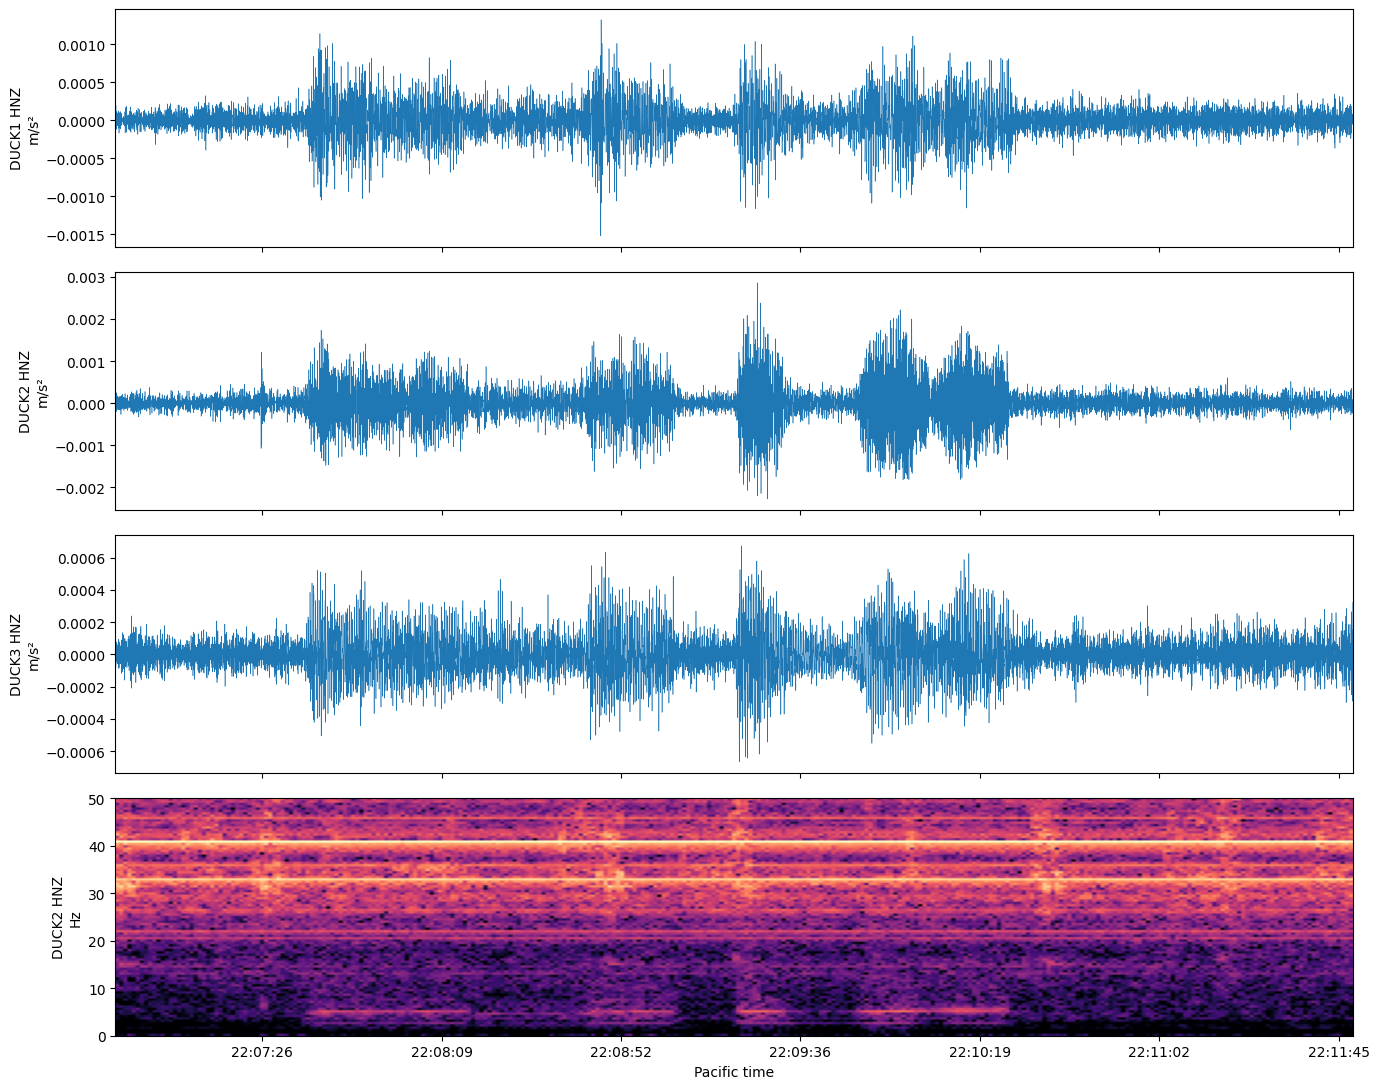

In [6]:
best = (0, None, None)
for sta in STATIONS:
    r = env[(sta, "Game")][k0:k1]
    k = int(np.argmax(r))
    if r[k] > best[0]:
        best = (r[k], sta, KICKOFF + k * WIN)
peak_rms, peak_sta, peak_t = best
t0, t1 = peak_t - 150, peak_t + 150
print(f"loudest 10 s in {BAND[0]:g}-{BAND[1]:g} Hz: {peak_sta} at "
      f"{peak_t.datetime.replace(tzinfo=UTC).astimezone(PT):%H:%M:%S} PT, RMS {peak_rms:.2e} m/s²")

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
for i, sta in enumerate(STATIONS):
    tr = game[sta].select(channel="HNZ")[0].slice(t0 - 30, t1 + 30).copy()
    tr.filter("bandpass", freqmin=BAND[0], freqmax=BAND[1], zerophase=True)
    tr = tr.slice(t0, t1)
    axes[i].plot(mpl_time(tr), tr.data, lw=0.4, color="C0")
    axes[i].set_ylabel(f"{sta} HNZ\nm/s²")
tr = game[peak_sta].select(channel="HNZ")[0].slice(t0, t1)
f, t, S = spec(tr, nperseg=400)
keep = f <= FMAX
axes[3].imshow(S[keep], aspect="auto", origin="lower", extent=[t[0], t[-1], 0, FMAX], cmap="magma",
               vmin=np.percentile(S[keep], 5), vmax=np.percentile(S[keep], 99.5))
axes[3].set_ylabel(f"{peak_sta} HNZ\nHz")
fmt_pt(axes[3], "%H:%M:%S")
axes[3].set_xlabel("Pacific time")
fig.tight_layout()

## Notes

- DUCK2 has strong mechanical noise above about 20 Hz on both nights. Any broadband amplitude metric is dominated by it. Everything crowd-related must be band-limited.
- The crowd band from section 3 is roughly 1 to 10 Hz, with the biggest lift at 2 to 8 Hz on all three stations. `BAND` above is the working choice for the fan shake meter and the relay's default bandpass. Update `config.toml` once it is settled.
- Play-by-play timestamps are not in this notebook yet. Once available, mark touchdowns on the section 4 envelope to build the "top 5 shakes" clip.